<a href="https://colab.research.google.com/github/swapna0727-source/AI/blob/main/cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("customer_segments.csv")
print(df.head())
print(df.columns.tolist())

   customer_id  annual_spend_k  purchase_frequency_per_month  \
0         9015            56.8                           2.7   
1         9011            10.1                          11.4   
2         9007            17.2                          11.5   
3         9028            28.5                           5.8   
4         9016            42.3                           1.5   

   avg_basket_value  loyalty_years  
0              3028            4.3  
1               623            0.9  
2               613            2.4  
3              1082            3.5  
4              3966            4.3  
['customer_id', 'annual_spend_k', 'purchase_frequency_per_month', 'avg_basket_value', 'loyalty_years']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   36 non-null     int64  
 1   annual_spend_k                36 non-null     float64
 2   purchase_frequency_per_month  36 non-null     float64
 3   avg_basket_value              36 non-null     int64  
 4   loyalty_years                 36 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 1.5 KB


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = df[["annual_spend_k", "purchase_frequency_per_month", "avg_basket_value", "loyalty_years"]]



In [ ]:
scaler = StandardScaler()
X_scaler = scaler.fit_transform(X)

In [ ]:
X_scaler

array([[ 1.83164871, -0.80318439,  0.78658205,  0.58994749],
       [-1.34263003,  1.67277379, -0.84480552, -1.30035547],
       [-0.86003091,  1.70123308, -0.85158883, -0.46639828],
       [-0.09195062,  0.07905358, -0.5334513 ,  0.14517033],
       [ 0.84605895, -1.14469586,  1.42285712,  0.58994749],
       [-0.69689881,  1.81507024, -0.88550541, -1.02236974],
       [-0.99597432,  0.73361724, -1.05576665, -1.46714691],
       [-0.22109686, -0.14862073, -0.58907449,  0.75673893],
       [-0.01718174, -0.5185915 , -0.20446046, -0.18841255],
       [ 1.70929963, -1.20161444,  1.2315676 ,  1.86868186],
       [-0.37063462, -0.31937647, -0.20988711,  0.36755891],
       [-0.58134691,  1.35972161, -1.01778008, -1.35595262],
       [ 1.13154012, -0.94548084,  1.96213076,  1.03472466],
       [-0.26187988, -0.03478358, -0.23091539, -0.68878687],
       [-0.41141764,  0.13597216, -0.26144032, -0.63318972],
       [ 1.28107788, -1.20161444,  0.45284289,  2.59144475],
       [ 0.38385134, -1.

In [ ]:
kmeans = KMeans(n_clusters = 3, random_state = 42, n_init = 10 )

In [ ]:
df["cluster"] = kmeans.fit_predict(X_scaler)

In [ ]:
df.head()

,customer_id,annual_spend_k,purchase_frequency_per_month,avg_basket_value,loyalty_years,cluster
0,9015,56.8,2.7,3028,4.3,1
1,9011,10.1,11.4,623,0.9,2
2,9007,17.2,11.5,613,2.4,2
3,9028,28.5,5.8,1082,3.5,0
4,9016,42.3,1.5,3966,4.3,1


In [ ]:
df["cluster"].value_counts()

,count
cluster,
0,13
2,12
1,11


In [ ]:
import seaborn as sns

In [ ]:
df.columns

Index(['customer_id', 'annual_spend_k', 'purchase_frequency_per_month',
       'avg_basket_value', 'loyalty_years', 'cluster'],
      dtype='object')

<Axes: xlabel='annual_spend_k', ylabel='avg_basket_value'>

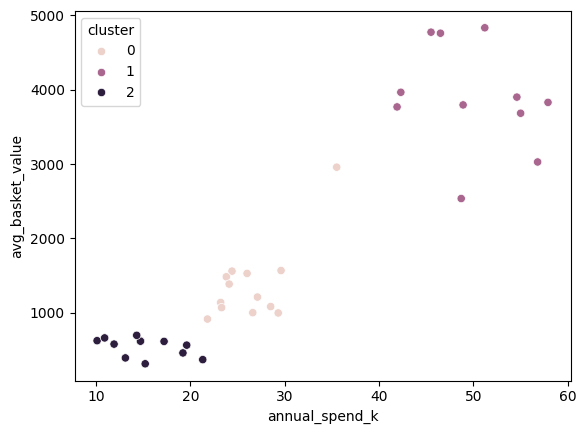

In [ ]:
sns.scatterplot(df, x ="annual_spend_k",  y = "avg_basket_value", hue = "cluster")

<Axes: xlabel='annual_spend_k', ylabel='purchase_frequency_per_month'>

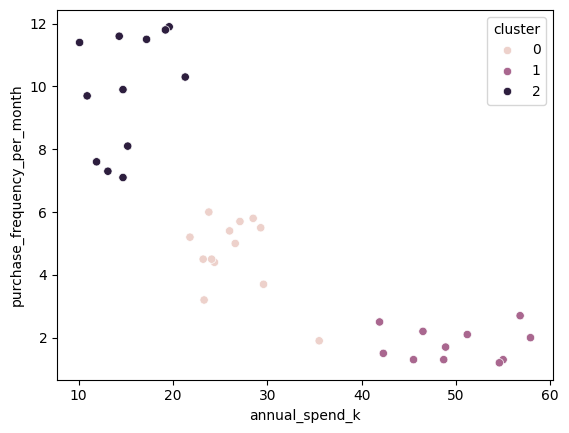

In [ ]:
sns.scatterplot(df, x ="annual_spend_k",  y = "purchase_frequency_per_month", hue = "cluster")

In [ ]:
inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaler)
    inertias.append(km.inertia_)
    print(k, round(km.inertia_, 2))

2 40.94
3 20.81
4 17.49
5 14.96
6 12.89
7 11.11


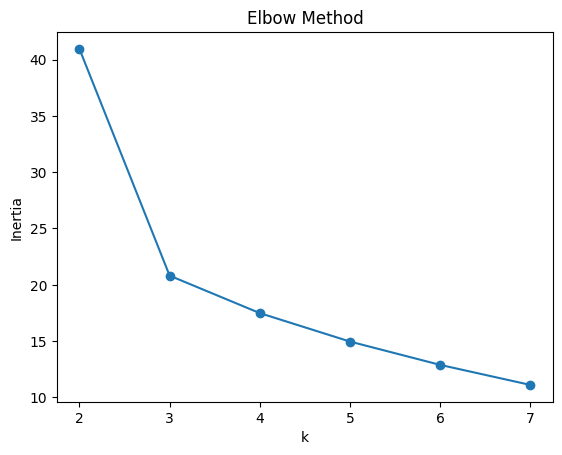

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(2, 8), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score # range is -1 to +1

sil_scores = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaler)
    sil = silhouette_score(X_scaler, labels)
    sil_scores.append(sil)
    print(k, round(sil, 3))

2 0.608
3 0.539
4 0.456
5 0.352
6 0.287
7 0.317


In [ ]:
cluster_profile = df.groupby("cluster")[["annual_spend_k", "purchase_frequency_per_month",
                                          "avg_basket_value", "loyalty_years"]].mean().round(2)
print(cluster_profile)

         annual_spend_k  purchase_frequency_per_month  avg_basket_value  \
cluster                                                                   
0                 26.40                          4.68           1375.92   
1                 49.94                          1.80           3898.18   
2                 15.18                          9.85            541.33   

         loyalty_years  
cluster                 
0                 2.92  
1                 5.42  
2                 1.58  


In [ ]:
churn_df = pd.read_csv("customer_churn.csv")

In [ ]:
churn_df.head()

,customer_id,age,monthly_spend,tenure_months,support_tickets,contract_type,used_mobile_app,churned
0,5001,36,839,41,0,Monthly,Yes,0
1,5002,24,1599,48,8,Monthly,Yes,1
2,5003,54,737,14,0,Monthly,No,1
3,5004,29,1836,38,0,Annual,No,0
4,5005,25,504,18,5,Monthly,Yes,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
X_churn = churn_df[["age", "monthly_spend", "tenure_months", "support_tickets",
                     "contract_type", "used_mobile_app"]]
y_churn = churn_df["churned"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_churn, y_churn, test_size=0.25, random_state=42, stratify=y_churn
)

In [ ]:
cat_cols = ["contract_type", "used_mobile_app"]
num_cols = ["age", "monthly_spend", "tenure_months", "support_tickets"]

pre_scaled = ColumnTransformer([
    ("cat", OneHotEncoder(drop="if_binary"), cat_cols),
    ("num", StandardScaler(), num_cols),
])
pre_plain = ColumnTransformer([("cat", OneHotEncoder(drop="if_binary"), cat_cols)], remainder="passthrough")


In [ ]:
pre_plain

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat', OneHotEncoder(drop='if_binary'),
                                 ['contract_type', 'used_mobile_app'])])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

churn_df = pd.read_csv("customer_churn.csv")
X_churn = churn_df[["age", "monthly_spend", "tenure_months", "support_tickets",
                     "contract_type", "used_mobile_app"]]
y_churn = churn_df["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X_churn, y_churn, test_size=0.25, random_state=42, stratify=y_churn
)

cat_cols = ["contract_type", "used_mobile_app"]
num_cols = ["age", "monthly_spend", "tenure_months", "support_tickets"]

pre_scaled = ColumnTransformer([
    ("cat", OneHotEncoder(drop="if_binary"), cat_cols),
    ("num", StandardScaler(), num_cols),
])
pre_plain = ColumnTransformer([("cat", OneHotEncoder(drop="if_binary"), cat_cols)], remainder="passthrough")

models = {
    "Logistic Regression": Pipeline([("pre", pre_scaled), ("model", LogisticRegression(max_iter=1000))]),
    "Decision Tree": Pipeline([("pre", pre_plain), ("model", DecisionTreeClassifier(max_depth=3, random_state=42))]),
    "Random Forest": Pipeline([("pre", pre_plain), ("model", RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42))]),
}

results = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 3),
        "Precision": round(precision_score(y_test, preds), 3),
        "Recall": round(recall_score(y_test, preds), 3),
        "F1": round(f1_score(y_test, preds), 3),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall    F1
Logistic Regression     0.889       0.80    1.00 0.889
      Decision Tree     0.778       0.75    0.75 0.750
      Random Forest     0.889       0.80    1.00 0.889


In [ ]:
rf_model = models["Random Forest"]
feature_names = rf_model.named_steps["pre"].get_feature_names_out()
importances = rf_model.named_steps["model"].feature_importances_

ranked = sorted(zip(feature_names, importances), key=lambda t: -t[1])
for name, score in ranked:
    print(f"{name}: {score:.4f}")

top_feature, top_score = ranked[0]
print(f"\nTop driver: {top_feature} ({top_score:.1%} of splitting usefulness)")

remainder__support_tickets: 0.2260
remainder__tenure_months: 0.1882
cat__contract_type_Monthly: 0.1836
remainder__monthly_spend: 0.1467
cat__used_mobile_app_Yes: 0.1329
remainder__age: 0.1226

Top driver: remainder__support_tickets (22.6% of splitting usefulness)


"[Model type] predicts [target] mainly based on [top feature]. In practice,
this means [plain business consequence] -- so [recommended action]."